In [56]:
import cv2
import numpy as np
import requests
from IPython.display import Image, display, clear_output
import time
from PIL import Image as PILImage
from io import BytesIO
from urllib.parse import urlencode
from detect import detect_multiple_colors, get_color_masks, estimate_distance_from_height
import threading
import time

In [57]:
# Function to set motors
def set_motors(jetbot_ip, left_speed, right_speed):
    params = {'left': left_speed, 'right': right_speed}
    url = f'http://{jetbot_ip}:8080/set_motors?{urlencode(params)}'
    response = requests.get(url)

    if response.status_code == 200:
        print("Motors set successfully")
    else:
        print("Failed to set motors")

In [58]:
# Function to execute left command
def move_left(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/left?{urlencode(params)}'
    response = requests.get(url)

    if response.status_code == 200:
        print("Left command executed successfully")
    else:
        print("Failed to execute left command")

In [59]:
# Function to execute right command
def move_right(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/right?{urlencode(params)}'
    response = requests.get(url)

    if response.status_code == 200:
        print("Right command executed successfully")
    else:
        print("Failed to execute right command")

In [60]:
# Function to execute forward command
def move_forward(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/forward?{urlencode(params)}'
    response = requests.get(url)

    if response.status_code == 200:
        print("Forward command executed successfully")
    else:
        print("Failed to execute forward command")

In [61]:
# Function to execute stop command
def stop_robot(jetbot_ip):
    url = f'http://{jetbot_ip}:8080/stop'
    response = requests.get(url)

    if response.status_code == 200:
        print("Stop command executed successfully")
    else:
        print("Failed to execute stop command")

In [62]:
def find_red_detection(detections):
    """
    Tries to find the largest red detection from different possible detection formats.
    Supports dictionaries like:
    {'color': 'red', 'bbox': (x, y, w, h)}
    {'name': 'red', 'box': (x, y, w, h)}
    {'label': 'red', 'x': ..., 'y': ..., 'w': ..., 'h': ...}
    """

    red_objects = []

    for det in detections:
        if isinstance(det, dict):
            color = (
                det.get("color")
                or det.get("name")
                or det.get("label")
                or det.get("class")
                or ""
            )

            if "red" not in str(color).lower():
                continue

            bbox = det.get("bbox") or det.get("box") or det.get("rect")

            if bbox is not None:
                x, y, w, h = bbox
            else:
                x = det.get("x")
                y = det.get("y")
                w = det.get("w") or det.get("width")
                h = det.get("h") or det.get("height")

                if None in [x, y, w, h]:
                    continue

            area = w * h
            red_objects.append((area, int(x), int(y), int(w), int(h), det))

        elif isinstance(det, (list, tuple)):
            # Example tuple formats:
            # ('red', x, y, w, h)
            # (x, y, w, h, 'red')
            if len(det) >= 5:
                if str(det[0]).lower() == "red":
                    _, x, y, w, h = det[:5]
                    area = w * h
                    red_objects.append((area, int(x), int(y), int(w), int(h), det))
                elif str(det[-1]).lower() == "red":
                    x, y, w, h = det[:4]
                    area = w * h
                    red_objects.append((area, int(x), int(y), int(w), int(h), det))

    if not red_objects:
        return None

    # Return largest red object
    red_objects.sort(reverse=True, key=lambda item: item[0])
    return red_objects[0]

In [63]:
def get_color_box(detections, target_color, min_area=100):
    for d in detections:
        if d["color"] == target_color and d["area"] >= min_area:
            return d
    return None

In [64]:
def box_is_centered(box, frame_width, tolerance_percent=0.20):
    box_center_x = box["x"] + box["w"] // 2
    camera_center_x = frame_width // 2

    tolerance_pixels = frame_width * tolerance_percent / 2

    return abs(box_center_x - camera_center_x) <= tolerance_pixels

In [65]:
def get_priority_color_box(detections, main_target, target_colors, min_area=100):
    """
    Always search for main_target first.
    If main_target is not found, search target_colors in order.

    Example:
    main_target = "red"
    target_colors = ["yellow", "blue", "black"]
    """

    # 1. Always try main target first
    main_box = get_color_box(detections, main_target, min_area)

    if main_box is not None:
        return main_box, main_target

    # 2. If main target not found, try other target colors
    for color in target_colors:
        box = get_color_box(detections, color, min_area)

        if box is not None:
            return box, color

    # 3. Nothing found
    return None, None

In [66]:
def spin_until_color_found(
    jetbot_ip,
    main_target="red",
    target_colors=["yellow"],
    spin_speed=0.10,
    min_area=100,
    tolerance_percent=0.10,
    step_time=0.15,
    pause_time=0.25,
    stop_event=None
):
    while stop_event is None or not stop_event.is_set():
        response = requests.get(f"http://{jetbot_ip}:8080/camera")

        pil_image = PILImage.open(BytesIO(response.content)).convert("RGB")
        frame_rgb = np.array(pil_image)
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

        height, width, _ = frame_bgr.shape

        detected_frame, counts, detections = detect_multiple_colors(frame_bgr)

        color_box, selected_color = get_priority_color_box(
            detections,
            main_target=main_target,
            target_colors=target_colors,
            min_area=min_area
        )

        if color_box is not None and box_is_centered(color_box, width, tolerance_percent):
            stop_robot(jetbot_ip)
            print(f"{selected_color} box is centered")
            return color_box, selected_color

        set_motors(jetbot_ip, spin_speed, -spin_speed)
        time.sleep(step_time)

        stop_robot(jetbot_ip)
        time.sleep(pause_time)

        clear_output(wait=True)
        detected_rgb = cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(detected_rgb))

        print("Searching...")
        print("main target:", main_target)
        print("backup targets:", target_colors)
        print("selected color:", selected_color)

    stop_robot(jetbot_ip)
    return None, None

In [67]:
def follow_color_step(
    jetbot_ip,
    main_target="red",
    target_colors=["yellow"],
    speed=0.12,
    turn=0.025,
    search_spin_speed=0.06,
    min_area=300,
    stop_px=75000,
    tolerance_percent=0.25
):
    response = requests.get(f"http://{jetbot_ip}:8080/camera")

    pil_image = PILImage.open(BytesIO(response.content)).convert("RGB")
    frame_rgb = np.array(pil_image)
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

    height, width, _ = frame_bgr.shape

    detected_frame, counts, detections = detect_multiple_colors(frame_bgr)

    # This chooses red first, then backup colors
    box, selected_color = get_priority_color_box(
        detections,
        main_target=main_target,
        target_colors=target_colors,
        min_area=min_area
    )

    if box is None:
        set_motors(jetbot_ip, search_spin_speed, -search_spin_speed)
        status = "searching"

    elif box["area"] >= stop_px:
        stop_robot(jetbot_ip)
        status = "reached"

    else:
        box_center_x = box["x"] + box["w"] // 2

        camera_center_x = width // 2
        error_x = box_center_x - camera_center_x

        tolerance_pixels = width * tolerance_percent / 2

        if abs(error_x) <= tolerance_pixels:
            left_speed = speed
            right_speed = speed

        elif error_x < 0:
            left_speed = speed - turn
            right_speed = speed + turn

        else:
            left_speed = speed + turn
            right_speed = speed - turn

        set_motors(jetbot_ip, left_speed, right_speed)
        status = "following"

    clear_output(wait=True)
    detected_rgb = cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB)
    display(PILImage.fromarray(detected_rgb))

    print("main target:", main_target)
    print("backup targets:", target_colors)
    print("selected color:", selected_color)
    print("status:", status)
    print("area:", None if box is None else box["area"])
    print("detections:", detections)

    return status, selected_color

In [68]:
main_target = "red"

shared_target_colors = []
target_lock = threading.Lock()

def add_target_color(color):
    with target_lock:
        if color not in shared_target_colors:
            shared_target_colors.append(color)
            print("Added new target color:", color)
            print("Current target colors:", shared_target_colors)

In [69]:
def get_shared_target_colors():
    with target_lock:
        return shared_target_colors.copy()

In [70]:
def display_camera_stream(jetbot_ip):
    while True:
        response = requests.get(f"http://{jetbot_ip}:8080/camera")

        pil_image = PILImage.open(BytesIO(response.content)).convert("RGB")
        frame_rgb = np.array(pil_image)
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

        height, width, _ = frame_bgr.shape

        # ---------------- SAMPLE TARGET COLOR ----------------

        box_w = int(width * 0.03)
        box_h = int(height * 0.12)

        box_w = max(box_w, 20)
        box_h = max(box_h, 20)

        x = width // 2 - box_w // 2
        y = height // 2 - box_h // 2
        w = box_w
        h = box_h

        crop = frame_bgr[y:y+h, x:x+w]

        crop_hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        average_hsv = crop_hsv.reshape(-1, 3).mean(axis=0)

        cv2.rectangle(frame_bgr, (x, y), (x + w, y + h), (255, 255, 255), 2)

        cv2.putText(
            frame_bgr,
            f"HSV: {average_hsv.astype(int)}",
            (max(x - 60, 0), max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            2
        )

        # ------------------------------------------------------

        detected_frame, counts, detections = detect_multiple_colors(frame_bgr)


        detected_rgb = cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB)
        output_image = PILImage.fromarray(detected_rgb)

        clear_output(wait=True)
        display(output_image)

        print(counts)
        print(detections)

        time.sleep(0.05)

In [71]:
def robot_loop(
    jetbot_ip,
    robot_color,
    main_target="red",
    speed=0.12,
    turn=0.025,
    search_spin_speed=0.1,
    min_area=300,
    stop_px=75000,
    tolerance_percent=0.25,
    stop_event=None
):
    try:
        while stop_event is None or not stop_event.is_set():

            current_target_colors = get_shared_target_colors()

            # Do not follow own color
            current_target_colors = [
                color for color in current_target_colors
                if color != robot_color
            ]

            status, selected_color = follow_color_step(
                jetbot_ip,
                main_target=main_target,
                target_colors=current_target_colors,
                speed=speed,
                turn=turn,
                search_spin_speed=search_spin_speed,
                min_area=min_area,
                stop_px=stop_px,
                tolerance_percent=tolerance_percent
            )

            print(jetbot_ip, "status:", status, "selected:", selected_color)

            if selected_color == main_target:
                add_target_color(robot_color)

            if status == "reached":
                stop_robot(jetbot_ip)
                print(jetbot_ip, "reached target")
                break

            if status == "searching":
                print(jetbot_ip, "starting segmented spin search")

                box, selected_color = spin_until_color_found(
                    jetbot_ip,
                    main_target=main_target,
                    target_colors=current_target_colors,
                    spin_speed=search_spin_speed,
                    min_area=min_area,
                    tolerance_percent=tolerance_percent,
                    step_time=0.15,
                    pause_time=0.25,
                    stop_event=stop_event
                )

                print(jetbot_ip, "spin result:", selected_color)

                if selected_color == main_target:
                    add_target_color(robot_color)

            time.sleep(0.05)

    finally:
        stop_robot(jetbot_ip)
        print(jetbot_ip, "stopped")

In [ ]:
# Example usage
# set_motors(jetbot_ip, 0.3, 0)
# move_left(jetbot_ip, 0.3)
# move_right(jetbot_ip, 0.3)
# move_forward(jetbot_ip, 0.3)
# stop_robot(jetbot_ip)

main_target = "red"

shared_target_colors = []   # starting backup colors
target_lock = threading.Lock()

# display_camera_stream(jetbot_ip_2)
stop_event = threading.Event()
stop_event.clear()

jetbot_ip_1 = "194.47.156.43"
jetbot_ip_2 = "194.47.156.201"

thread_1 = threading.Thread(
    target=robot_loop,
    args=(jetbot_ip_1,),
    kwargs={
        "robot_color": "yellow",
        "main_target": "red",
        "stop_event": stop_event
    }
)

thread_2 = threading.Thread(
    target=robot_loop,
    args=(jetbot_ip_2,),
    kwargs={
        "robot_color": "blue",
        "main_target": "red",
        "stop_event": stop_event
    }
)

thread_1.start()
thread_2.start()

Measured box height px: 11
Measured box height px: 48
Measured box height px: 38
Measured box height px: 150
Motors set successfully
Motors set successfully
main target: red
backup targets: []
selected color: red
status: following
area: 11966.0
detections: [{'color': 'red', 'x': 679, 'y': 20, 'w': 84, 'h': 150, 'area': 11966.0, 'distance_cm': 133.6}]
194.47.156.43 status: following selected: red
Added new target color: yellow
Current target colors: ['yellow']
main target: red
backup targets: []
selected color: red
status: following
area: 638.0
detections: [{'color': 'purple', 'x': 383, 'y': 77, 'w': 11, 'h': 11, 'area': 100.0, 'distance_cm': 636.3636363636364}, {'color': 'yellow', 'x': 361, 'y': 0, 'w': 50, 'h': 48, 'area': 2067.0, 'distance_cm': 145.83333333333334}, {'color': 'red', 'x': 500, 'y': 20, 'w': 27, 'h': 38, 'area': 638.0, 'distance_cm': 527.3684210526316}]
194.47.156.201 status: following selected: red
Added new target color: blue
Current target colors: ['yellow', 'blue']


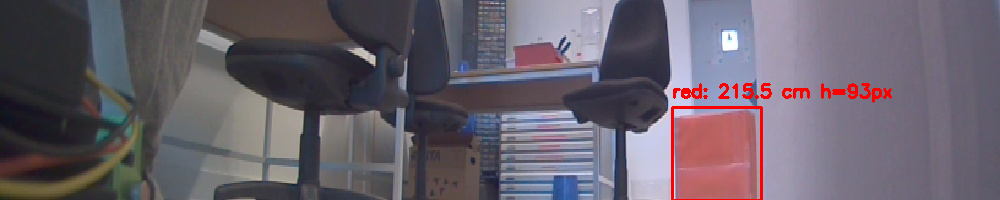

In [ ]:
# stop_event.set()
# stop_robot(jetbot_ip_2)

# stop_robot(jetbot_ip_1)


# thread_1.join()
# thread_2.join()